In [1]:
from pathlib import Path
from PIL import Image
import numpy as np

# Inspect the images

In [2]:
DATA_DIR = Path("../data/raw")
image_paths = sorted(DATA_DIR.glob("*.png"))

print(f"Number of images: {len(image_paths)}")

Number of images: 375


In [3]:
img = Image.open(image_paths[0])

print(f"Filename: {image_paths[0].name}")
print(f"Size: {img.size}")
print(f"Mode: {img.mode}")

arr = np.array(img)

print(f"Array shape: {arr.shape}")
print(f"Data type: {arr.dtype}")
print(f"Min value: {arr.min()}")
print(f"Max value: {arr.max()}")

Filename: 100700_TEVP_10_IVsVg_b1.png
Size: (771, 790)
Mode: RGBA
Array shape: (790, 771, 4)
Data type: uint8
Min value: 0
Max value: 255


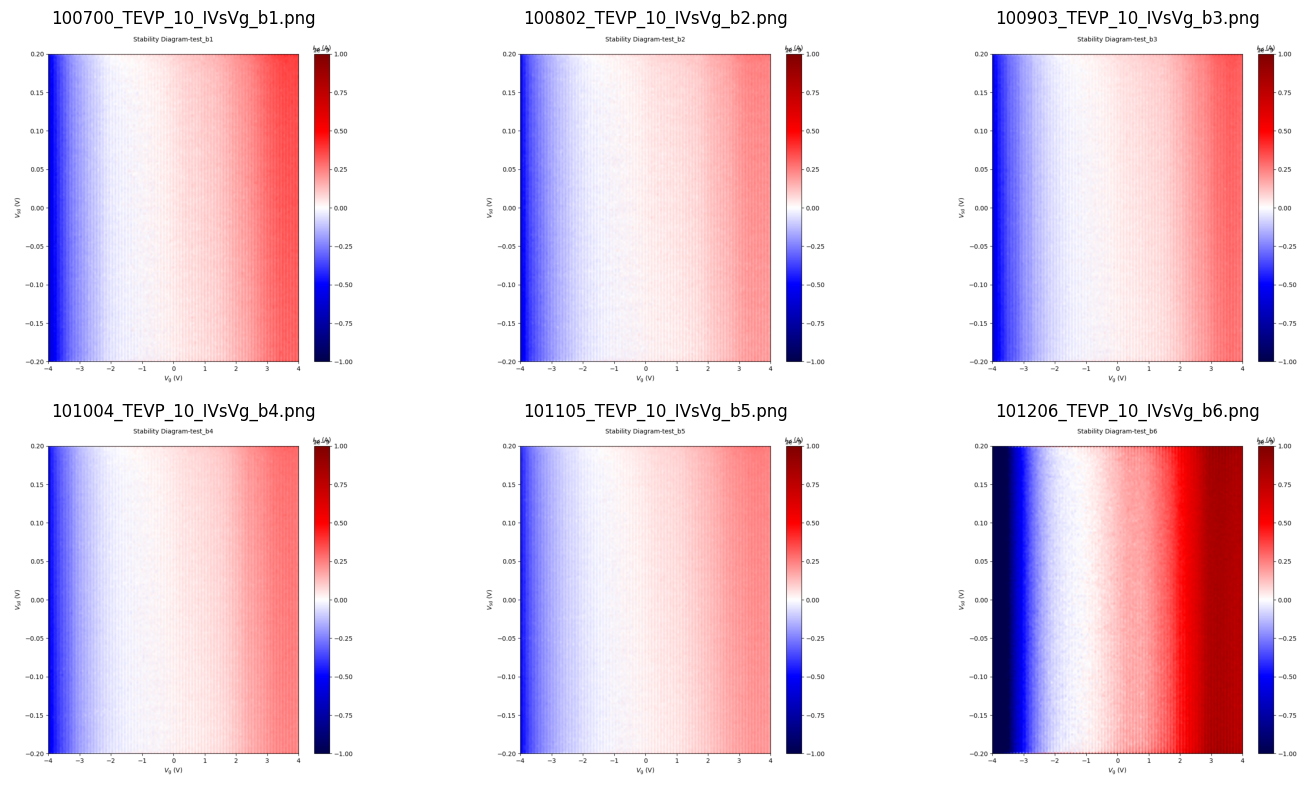

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, path in zip(axes.flat, image_paths[:6]):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()

In [5]:
from collections import Counter

sizes = []
modes = []
alpha_values = []

for path in image_paths:
    img = Image.open(path)

    sizes.append(img.size)
    modes.append(img.mode)

    if img.mode == "RGBA":
        alpha = np.array(img)[:, :, 3]
        alpha_values.append((alpha.min(), alpha.max()))

print("Image sizes:")
print(Counter(sizes))

print("\nImage modes:")
print(Counter(modes))

print("\nAlpha ranges:")
print(Counter(alpha_values))

Image sizes:
Counter({(773, 790): 147, (771, 790): 126, (770, 790): 59, (772, 790): 43})

Image modes:
Counter({'RGBA': 375})

Alpha ranges:
Counter({(np.uint8(255), np.uint8(255)): 375})


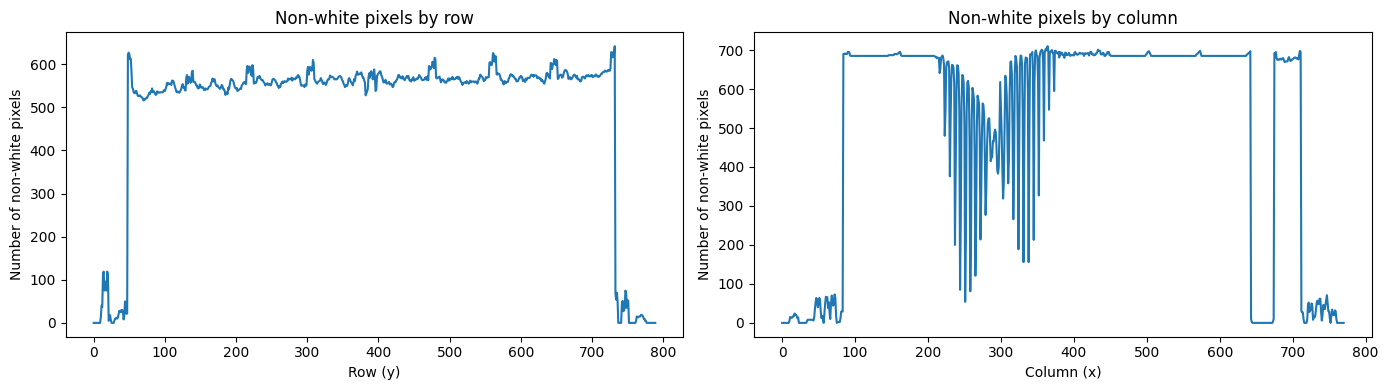

In [7]:
img = np.array(Image.open(image_paths[0]))[:, :, :3]

# Find pixels that are not approximately white
non_white = np.any(img < 245, axis=2)

# Number of non-white pixels in each row/column
row_counts = non_white.sum(axis=1)
col_counts = non_white.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(row_counts)
axes[0].set_title("Non-white pixels by row")
axes[0].set_xlabel("Row (y)")
axes[0].set_ylabel("Number of non-white pixels")

axes[1].plot(col_counts)
axes[1].set_title("Non-white pixels by column")
axes[1].set_xlabel("Column (x)")
axes[1].set_ylabel("Number of non-white pixels")

plt.tight_layout()

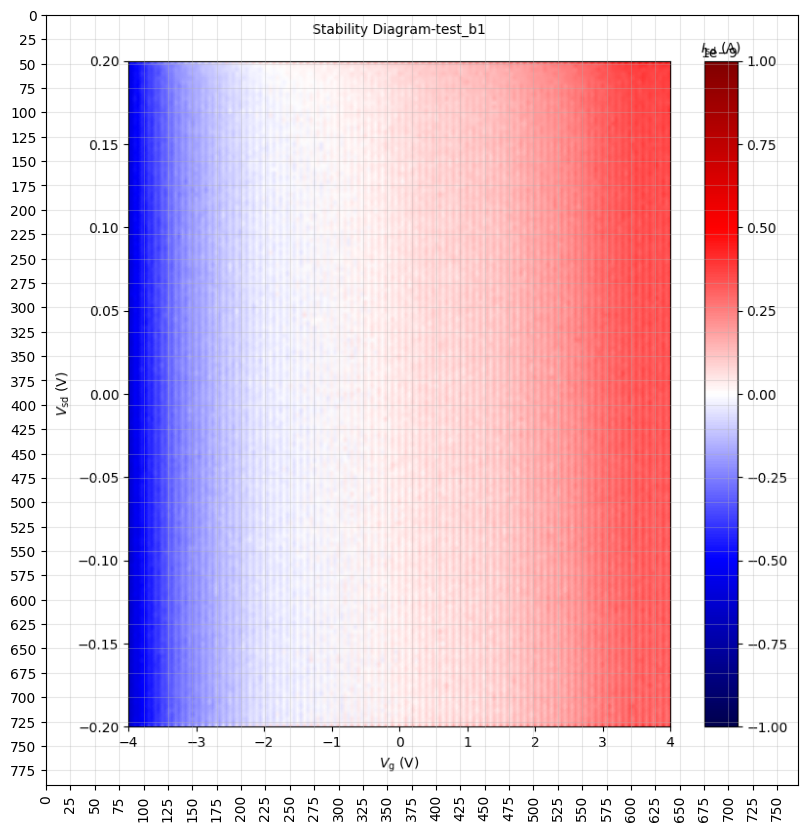

In [9]:
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.xlim(0, img.shape[1])
plt.ylim(img.shape[0], 0)

# Grid every 25 pixels
plt.xticks(range(0, img.shape[1], 25), rotation=90)
plt.yticks(range(0, img.shape[0], 25))

plt.grid(alpha=0.3)
plt.show()

Original: (790, 771, 3)
Cropped: (675, 535, 3)


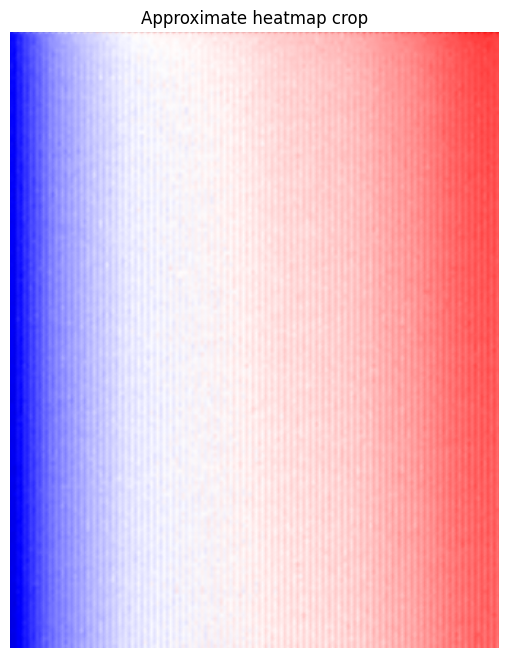

In [14]:
# Approximate heatmap crop
left = 90
top = 50
right = 625
bottom = 725

cropped = img[top:bottom, left:right]

print("Original:", img.shape)
print("Cropped:", cropped.shape)

plt.figure(figsize=(8, 8))
plt.imshow(cropped)
plt.axis("off")
plt.title("Approximate heatmap crop")
plt.show()

# Implement the preprocessing

The above experiment shows that there is no alpha used in any of the images, and most of the images adhere to a fixed coordinate with only some minor deviation, as a result the following pixel locations will be used to crop the image:
- left = 100
- top = 60
- right = 625
- bottom = 725

In [48]:
left = 100
top = 60
right = 625
bottom = 725

img = Image.open(image_paths[360]).convert("RGB")
cropped = img.crop((left, top, right, bottom))
gray = cropped.convert("L")

print("Original:", img.size)
print("Cropped:", cropped.size)
print("Grayscale:", gray.size)

Original: (773, 790)
Cropped: (525, 665)
Grayscale: (525, 665)


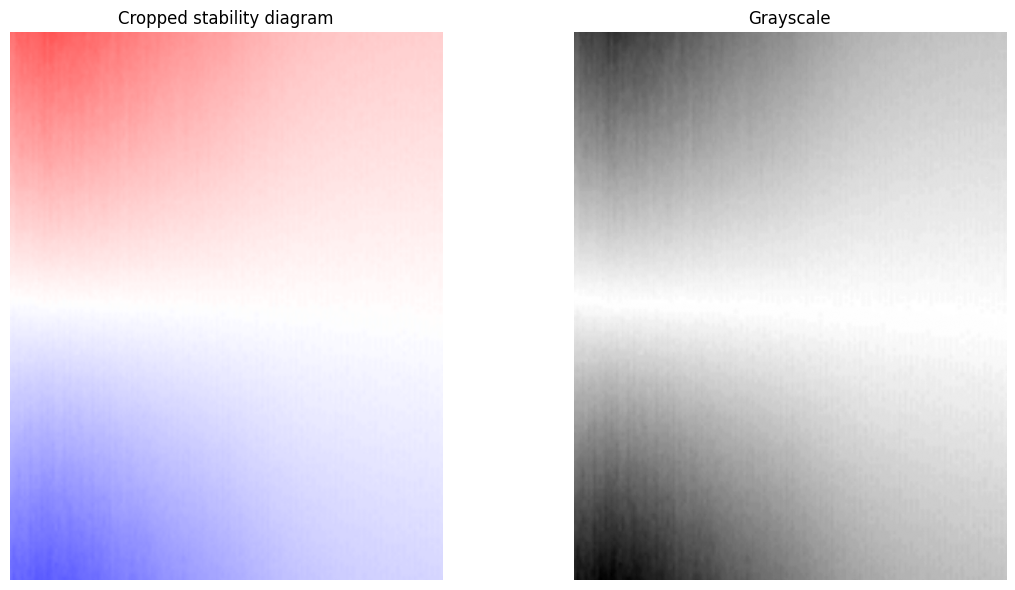

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cropped)
axes[0].set_title("Cropped stability diagram")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

plt.tight_layout()

In [50]:
def preprocess_image(path: Path) -> np.ndarray:
    """
    Preprocess an image: crop and convert to grayscale.

    Args:
        path (Path): Path to the image file.

    Returns:
        np.ndarray: Preprocessed grayscale image as a NumPy array.
    """
    img = Image.open(path).convert("RGB")
    cropped = img.crop((100, 60, 625, 725))
    gray = cropped.convert("L")
    return np.array(gray)

In [52]:
preprocessed_images = [preprocess_image(path) for path in image_paths]
processed_images = np.array(preprocessed_images)

print("Processed dataset shape:", processed_images.shape)
print("Data type:", processed_images.dtype)
print("Pixel range:", processed_images.min(), "to", processed_images.max())

Processed dataset shape: (375, 665, 525)
Data type: uint8
Pixel range: 0 to 254


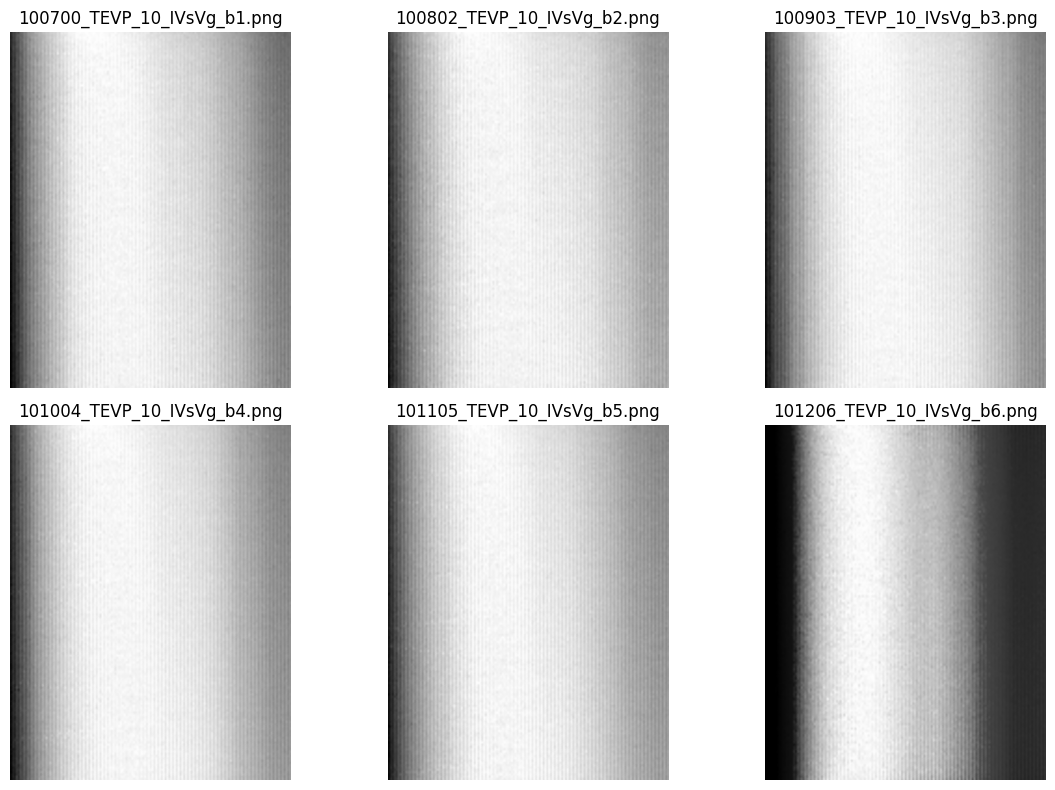

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, image, path in zip(axes.flat, processed_images[:6], image_paths[:6]):
    ax.imshow(image, cmap="gray")
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()

In [56]:
import pandas as pd

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

image_paths = sorted(RAW_DIR.glob("*.png"))

mapping = []

for i, path in enumerate(image_paths, start=1):
    image_id = f"image_{i:03d}"

    # Load → crop → grayscale
    img = Image.open(path).convert("RGB")
    cropped = img.crop((100, 60, 625, 725))
    gray = cropped.convert("L")

    # Save processed image
    output_path = PROCESSED_DIR / f"{image_id}.png"
    gray.save(output_path)

    mapping.append({
        "image_id": image_id,
        "original_filename": path.name
    })

mapping_df = pd.DataFrame(mapping)

mapping_df.to_csv(
    PROCESSED_DIR / "image_mapping.csv",
    index=False
)

print(f"Processed {len(mapping_df)} images.")
print(mapping_df.head())

Processed 375 images.
    image_id            original_filename
0  image_001  100700_TEVP_10_IVsVg_b1.png
1  image_002  100802_TEVP_10_IVsVg_b2.png
2  image_003  100903_TEVP_10_IVsVg_b3.png
3  image_004  101004_TEVP_10_IVsVg_b4.png
4  image_005  101105_TEVP_10_IVsVg_b5.png
